# Recombination modeling: Thomas–Imel + empirical fits

This notebook loads the processed `*_s2_vs_drift.csv` files that already include the `recomb_factor` (recombination fraction) column, fits the Thomas–Imel model and a simple empirical model to `recomb_factor(E_d)`, and produces diagnostic plots and a small table of fitted parameters.

Notes: we *do not* recompute gS2 or N_e here — the CSVs already contain `recomb_factor` as you requested. Adjust the `files` list below to point to whichever runs you want analysed.

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit
import json
%matplotlib inline

In [20]:
# Example file list: replace or extend with your CSV paths
files = [
    '/Volumes/KINGSTON/RaTag_data/RUN23_Ra224/processed_data/RUN_23_recomb_factors.csv',
    '/Volumes/KINGSTON/RaTag_data/RUN26_Th228_EL2700/processed_data/RUN_26_recomb_factors.csv'
]

# Optional labels for plots (same length as files)
labels = ['Run23 - Ra224, EL 2.35 kV/cm', 'Run26 - Th228, Bias EL 3.35 kV/cm']

In [14]:
def load_recomb_csv(path):
    df = pd.read_csv(path)
    # Expect columns: 'drift_field' (V/cm), 'recomb_factor' and optional 'recomb_uncert'
    if 'recomb_factor' not in df.columns:
        raise ValueError(f'run file {path} does not contain column')
    x = df['drift_field'].values.astype(float)
    y = df['recomb_factor'].values.astype(float)
    if 'recomb_uncert' in df.columns:
        yerr = df['recomb_uncert'].values.astype(float)
    elif 'recomb_ci95' in df.columns:
        yerr = df['recomb_ci95'].values.astype(float)
    else:
        yerr = np.full_like(y, 0.05 * np.maximum(0.1, np.abs(y)))  # fallback 5% or 0.05 absolute
    return x, y, yerr, df

In [13]:
df = pd.read_csv(files[1])
df

,set_name,drift_field,s2_mean,s2_ci95,s2_sigma,N_e_meas,dN_e_meas,recomb_factor,recomb_error
0,FieldScan_Gate0050_Anode2750,35.714,1.311000,0.264,0.939000,365.571055,73.616139,0.916916,0.016731
1,FieldScan_Gate0100_Anode2800,71.429,1.231000,0.176,1.572000,343.263134,49.077426,0.921986,0.011154
2,FieldScan_Gate0200_Anode2900,142.857,1.928000,0.088,1.669000,537.620896,24.538713,0.877813,0.005577
3,FieldScan_Gate0300_Anode3000,214.286,2.503000,0.055,1.946000,697.959078,15.336696,0.841373,0.003486
4,FieldScan_Gate0500_Anode3200,357.143,3.048000,0.069,2.258000,849.931790,19.240582,0.806834,0.004373
5,FieldScan_Gate0700_Anode3400,500.000,3.403000,0.070,2.407000,948.923189,19.519431,0.784336,0.004436
6,FieldScan_Gate1000_Anode3700,714.286,3.704000,0.069,2.663000,1032.856742,19.240582,0.765260,0.004373
7,FieldScan_Gate1200_Anode3900,857.143,3.895803,0.000,2.913829,1086.340819,0.000000,0.753104,0.000000


In [22]:
# Models
def r_thomas_imel(E, a):
    # a has units of (E * xi) ~ (E * (C*N_i)) so E in V/cm yields dimensionless xi = a/E
    E = np.asarray(E, dtype=float)
    xi = a / E
    # prevent division by zero/nans
    with np.errstate(divide='ignore', invalid='ignore'):
        out = 1.0 - np.log1p(xi) / xi
    # handle xi -> 0 limit (small xi => out ~ xi/2 -> 0)
    small = np.isclose(xi, 0)
    out[small] = 0.0
    return out

def r_empirical(E, A, B):
    E = np.asarray(E, dtype=float)
    return A / (1.0 + B * E)

def r_empirical_p(E, A, B, p):
    E = np.asarray(E, dtype=float)
    return A / (1.0 + B * E**p)

In [5]:
def fit_model(x, y, yerr, model, p0=None, bounds=(-np.inf, np.inf)):
    # Use curve_fit with sigma = yerr for weighted fit
    try:
        popt, pcov = curve_fit(model, x, y, p0=p0, sigma=yerr, absolute_sigma=True, bounds=bounds, maxfev=10000)
    except Exception as e:
        print('Fit failed:', e)
        return None, None
    perr = np.sqrt(np.diag(pcov))
    return popt, perr

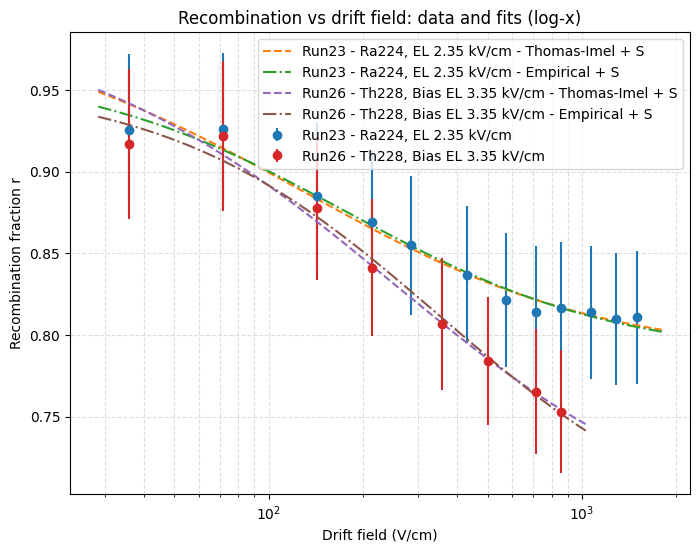

In [23]:
# Loop over files, fit models with a multiplicative extraction efficiency S, and plot
results = []
plt.figure(figsize=(8, 6))
# Define observed-model wrappers that include S (0 < S <= 1)
def r_thomas_imel_obs(E, a, S):
    return 1.0 - S * (1.0 - r_thomas_imel(E, a))

def r_empirical_obs(E, A, B, S):
    return 1.0 - S * (1.0 - r_empirical(E, A, B))

for i, f in enumerate(files):
    label = labels[i] if i < len(labels) else Path(f).stem
    x, y, yerr, df = load_recomb_csv(f)
    # sort by x
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    yerr = yerr[order]

    # Fit Thomas-Imel with S: initial guesses [a, S]
    p0_ti = [500.0, 0.9]
    bounds_ti = ([1e-6, 0.0], [1e6, 1.0])
    popt_ti, perr_ti = fit_model(x, y, yerr, r_thomas_imel_obs, p0=p0_ti, bounds=bounds_ti)

    # Fit empirical A/(1+B E) with multiplicative S: [A, B, S]
    p0_emp = [min(1.0, max(0.99, np.max(y))), 1.0 / max(1.0, np.mean(x)), 0.9]
    bounds_emp = ([0.0, 0.0, 0.0], [2.0, 1e4, 1.0])
    popt_emp, perr_emp = fit_model(x, y, yerr, r_empirical_obs, p0=p0_emp, bounds=bounds_emp)

    # Save results
    results.append({
        'file': f,
        'label': label,
        'x': x,
        'y': y,
        'yerr': yerr,
        'popt_ti': popt_ti,
        'perr_ti': perr_ti,
        'popt_emp': popt_emp,
        'perr_emp': perr_emp
    })

    # Plot data + fits on the same axes for quick comparison
    xfine = np.logspace(np.log10(max(1.0, x.min()*0.8)), np.log10(x.max()*1.2), 200)
    plt.errorbar(x, y, yerr=yerr, fmt='o', label=label)
    if popt_ti is not None:
        plt.plot(xfine, r_thomas_imel_obs(xfine, *popt_ti), '--', label=f'{label} - Thomas-Imel + S')
    if popt_emp is not None:
        plt.plot(xfine, r_empirical_obs(xfine, *popt_emp), '-.', label=f'{label} - Empirical + S')

plt.xscale('log')
plt.xlabel('Drift field (V/cm)')
plt.ylabel('Recombination fraction r')
plt.title('Recombination vs drift field: data and fits (log-x)')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.show()

In [26]:
results[0]

{'file': '/Volumes/KINGSTON/RaTag_data/RUN23_Ra224/processed_data/RUN_23_recomb_factors.csv',
 'label': 'Run23 - Ra224, EL 2.35 kV/cm',
 'x': array([  35.714,   71.429,  142.857,  214.286,  285.714,  428.571,
         571.429,  714.286,  857.143, 1071.429, 1285.714, 1500.   ]),
 'y': array([0.92559801, 0.92635851, 0.88535503, 0.86919446, 0.85487176,
        0.83706345, 0.82140988, 0.81405841, 0.81646665, 0.81386828,
        0.80987567, 0.81076292]),
 'yerr': array([0.0462799 , 0.04631793, 0.04426775, 0.04345972, 0.04274359,
        0.04185317, 0.04107049, 0.04070292, 0.04082333, 0.04069341,
        0.04049378, 0.04053815]),
 'popt_ti': array([2.83818046e+02, 2.11906969e-01]),
 'perr_ti': array([2.09706253e+02, 3.16961117e-02]),
 'popt_emp': array([0.8346096 , 0.00561201, 0.21407444]),
 'perr_emp': array([0.3531584 , 0.00860449, 0.04209655])}

In [24]:
# Summarize results into a DataFrame and save
rows = []
for r in results:
    row = {
        'file': r['file'],
        'label': r['label']
    }
    if r['popt_ti'] is not None:
        row.update({'ti_a': float(r['popt_ti'][0]), 'ti_a_err': float(r['perr_ti'][0]) if r['perr_ti'] is not None else None})
    else:
        row.update({'ti_a': None, 'ti_a_err': None})
    if r['popt_emp'] is not None:
        row.update({'emp_A': float(r['popt_emp'][0]), 'emp_A_err': float(r['perr_emp'][0]) if r['perr_emp'] is not None else None,
                    'emp_B': float(r['popt_emp'][1]), 'emp_B_err': float(r['perr_emp'][1]) if r['perr_emp'] is not None else None})
    else:
        row.update({'emp_A': None, 'emp_A_err': None, 'emp_B': None, 'emp_B_err': None})
    rows.append(row)
df_results = pd.DataFrame(rows)
out_csv = Path('recombination_fit_results.csv')
# df_results.to_csv(out_csv, index=False)
print('Saved fit summary to', out_csv)
df_results

Saved fit summary to recombination_fit_results.csv


,file,label,ti_a,ti_a_err,emp_A,emp_A_err,emp_B,emp_B_err
0,/Volumes/KINGSTON/RaTag_data/RUN23_Ra224/proce...,"Run23 - Ra224, EL 2.35 kV/cm",283.818046,209.706253,0.83461,0.353158,0.005612,0.008604
1,/Volumes/KINGSTON/RaTag_data/RUN26_Th228_EL270...,"Run26 - Th228, Bias EL 3.35 kV/cm",545.681389,422.962441,0.86519,0.159537,0.002852,0.004132


## SRIM / Thomas–Imel applicability comment

You reported SRIM numbers for Ra2+ in xenon at 2 bar: projected range ~27.85 µm with longitudinal and lateral straggling of ~13.3 µm and ~9.8 µm. These are very short tracks (tens of microns), so the initial ionization cloud is spatially compact. The Thomas–Imel box model is intended for such compact, low‑track‑length depositions where geminate/volume recombination within a small region dominates, so it is a reasonable first model to apply.

Caveat: Thomas–Imel assumes uniform box approximation and certain kinetics; if the track geometry is strongly nonuniform (large dE/dx gradients) or if columnar effects become important, you may need an alternative (columnar/Jaffé) or a hybrid empirical model. The fitting notebook above allows direct comparison of the Thomas–Imel fit quality vs a simple empirical model to help decide which is more appropriate.

## Next diagnostics and suggestions

- Confirm `recomb_factor` extraction: make sure the CSVs use the same N_i/W assumption for each isotope and note any differences.
- For the silicon bias effect (panel a): plot the alpha spectra for the two biases and overlay the chosen ROI; if the ROI is shifting or slicing the peak differently, that may explain much of the difference.
- Use the notebook to fit runs with different EL fields: if Thomas–Imel fits require different `a` parameters but empirical fits indicate a multiplicative scale change, that suggests an extraction/gS2 effect rather than recombination physics alone.
- Consider adding a model term for an extraction efficiency `eps(E_EL, E_d)` if fits show a multiplicative mismatch across EL field runs.

If you want, I can: (A) run this notebook locally against your example CSVs and return the fit result CSV + PNGs, or (B) adapt the notebook to perform a simultaneous multi-run fit where `a` scales with N_i (if you provide N_i) and `eps` is a per-run nuisance parameter. Which do you prefer?